### DEFINICIÓN DE MG1

In [1]:
import probEDNR as edr
import numpy as np
import logging

# Solar STC(1kW/m2) nominal curve
spv_nomcurve=np.array([0]*6+[0.038, 0.188, 0.421,
       0.676, 0.883, 0.988, 0.962, 0.812, 0.579, 0.324, 0.117, 0.012]+[0]*6)

## DEF MG1

Diesel1=edr.Generator('Diesel',rate_copkwh=910,power_perunit_kw=[1750,1275,1000,1000,910,510],UR=1500,DR=1500)
Biomass1=edr.Generator('Biomass',480,[560]*4,UR=3*200,DR=3*200)
demc1=np.array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,0.786, 0.837,
       0.878, 0.878, 0.959, 1., 0.98 , 0.959, 0.918,0.939, 0.959, 0.98 , 0.994, 0.959, 0.898])
## + SPV (4.5MWp)
SPV_MPPT_1=edr.Generator('SPV',80,[250]*18,IBR=2,gen_curve_pu=spv_nomcurve) 
## + BESS (default based on Pylontech US5000)
BESS1=edr.BESS(nmods=280)
MG1=edr.MG(5300,demc1,True,Gens=(SPV_MPPT_1,Diesel1,Biomass1),BESS=BESS1)
# print(f"MG1 is: {MG1}")
MG1_nobat=edr.MG(5300,demc1,False,Gens=(SPV_MPPT_1,Diesel1,Biomass1))

Ntests=10
LastInstanceGen='Diesel'
initopts={
'logger_level':logging.DEBUG,
'logger_scope':2,
'seed':42,
'strictlycircularbess':False,
'BESS_SOE_init':0.4
}
resopts={
'Res_verbose':True,
'fpart_bess':0.4,
'T_RB_dc_h':1,
'T_RB_ch_h':1
}
resopts2={
'Res_verbose':True,
'fpart_bess':0.6,
'T_RB_dc_h':1,
'T_RB_ch_h':1,
'rwass':10,
'Q':100
}

# runSimulations w several sample sizes for detED
NsampSizes=4
SampSizes=np.linspace(20,200,NsampSizes).astype(int)
# SampSizes
Nexp=3 #N experiments per SampleSize
Ntest=5

# Init MG solver
# MG1_det=edr.detEDnR(MG1,**initopts)
# MG1_det=edr.SEDnR(MG1,**initopts)
# MG1_det=edr.REDnR(MG1,**initopts)
MG1_det=edr.DRWEDnR(MG1,**initopts)
paramRange=[resopts2] # IF YOU WANT MORE YOU NEED TO ADAPT RESHAPES
MG1_det.LastInstance=LastInstanceGen
hasbess=MG1_det.HAS_BESS
# Init Results
metric_names = [ 'PrViol']
results={'Nsamp':np.zeros(NsampSizes)}
results|={m: np.zeros((NsampSizes,Nexp)) for m in ['Jis', 'Joos', 'rel']}
results|={'PrViol':np.zeros((NsampSizes,Nexp,1+hasbess))}
# One test set for all
TestSet=MG1_det.generateSampleSet(Ntest)

for isz,sz in enumerate(SampSizes):
    # Por cada size, Nexper SampleSets
    TrainSets = [MG1_det.generateSampleSet(sz) for _ in range(Nexp)]
    print(f"Nsamples: {sz}")
    _xdec,Jis,Joos,rel,PrViol=MG1_det.runSimulations(TrainSets,TestSet,paramRange)
    results['Nsamp'][isz]=sz
#     print(Jis)
    results['Jis'][isz,:]=np.array(Jis).reshape(1,Nexp)
#     print(results['Jis'])
    results['Joos'][isz,:]=np.array(Joos).reshape(1,Nexp)
    results['rel'][isz,:]=np.array(rel).reshape(1,Nexp)
    print(PrViol)
    results['PrViol'][isz,:]=np.array(PrViol).reshape((1,Nexp,1+hasbess))
#     print(results['PrViol'])

[probEDNR.py:448 - __init__()] Instance set for non-transactive EDnR
[probEDNR.py:451 - __init__()] No training sample provided for Model. Set when solving (non det-nominal).


Set parameter Username
Set parameter LicenseID to value 2708525


[probEDNR.py:478 - CreateModel()] Model "Jan09_171635" created
[probEDNR.py:1166 - updateNominaltoSampleSetMean()] previous nominal Day: {'peak_demand_kw': 5300, 'demand_curve_kw': array([4542.1, 4489.1, 4218.8, 3990.9, 3948.5, 3784.2, 3566.9, 3784.2,
       4054.5, 4165.8, 4436.1, 4653.4, 4653.4, 5082.7, 5300. , 5194. ,
       5082.7, 4865.4, 4976.7, 5082.7, 5194. , 5268.2, 5082.7, 4759.4]), 'demand_curve_pu': array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,
       0.786, 0.837, 0.878, 0.878, 0.959, 1.   , 0.98 , 0.959, 0.918,
       0.939, 0.959, 0.98 , 0.994, 0.959, 0.898]), 'Psolar_kw': array([   0. ,    0. ,    0. ,    0. ,    0. ,    0. ,  171. ,  846. ,
       1894.5, 3042. , 3973.5, 4446. , 4329. , 3654. , 2605.5, 1458. ,
        526.5,   54. ,    0. ,    0. ,    0. ,    0. ,    0. ,    0. ])}
[probEDNR.py:1169 - updateNominaltoSampleSetMean()] expected, new nominal Day: namespace(demand_curve_kw=array([4565., 4468., 4157., 3974., 3948., 3772., 3587., 3788.

Nsamples: 20


[probEDNR.py:2765 - solve_drow()] solving...
[probEDNR.py:2774 - solve_drow()] ED solved optimally in 0.00 seconds
[probEDNR.py:178 - Joos()] Joos_: (61663065.82039548, 61471759.77072319, 61136737.35907364, 60843309.216368616, 64122433.343163535)
[probEDNR.py:179 - Joos()] PrViol_: [(0.10555555555555556, 0.10555555555555556, 0.16527777777777777, 0.1527777777777778, 0.15138888888888888), (0.25, 0.0, 0.3333333333333333, 0.20833333333333334, 0.5)]
[probEDNR.py:181 - Joos()] Joos,PrViol: (61847461.101944886, [0.13611111111111113, 0.2583333333333333])
[probEDNR.py:536 - solveTest()] Jis: 60584552.97573921
[probEDNR.py:537 - solveTest()] prvio: [0.13611111111111113, 0.2583333333333333]
[probEDNR.py:240 - simulate()] Jis: [60584552.97573921]
[probEDNR.py:241 - simulate()] prvio3: [[0.13611111111111113, 0.2583333333333333]]
[probEDNR.py:521 - solveTest()] New sample size. Recreating whole model and solving lol.


...

[[[0.13611111111111113, 0.2583333333333333]], [[0.12555555555555556, 0.225]], [[0.13166666666666668, 0.20833333333333334]]]


[probEDNR.py:521 - solveTest()] New sample size. Recreating whole model and solving lol.


Nsamples: 80
Set parameter Username
Set parameter LicenseID to value 2708525


[probEDNR.py:478 - CreateModel()] Model "Jan09_171642" created
[probEDNR.py:1166 - updateNominaltoSampleSetMean()] previous nominal Day: {'peak_demand_kw': 5300, 'demand_curve_kw': array([4598., 4527., 4271., 4023., 3993., 3805., 3590., 3865., 4136.,
       4237., 4454., 4704., 4709., 5133., 5322., 5215., 5080., 4944.,
       5018., 5157., 5321., 5283., 5074., 4801.]), 'demand_curve_pu': array([0.86754717, 0.85415094, 0.80584906, 0.7590566 , 0.75339623,
       0.71792453, 0.67735849, 0.72924528, 0.78037736, 0.79943396,
       0.84037736, 0.88754717, 0.88849057, 0.96849057, 1.00415094,
       0.98396226, 0.95849057, 0.93283019, 0.94679245, 0.97301887,
       1.00396226, 0.99679245, 0.95735849, 0.90584906]), 'Psolar_kw': array([   0.,    0.,    0.,    0.,    0.,    4.,  274., 1085., 2055.,
       2818., 3312., 3476., 3396., 2957., 2356., 1695.,  935.,  308.,
         34.,    0.,    0.,    0.,    0.,    0.])}
[probEDNR.py:1169 - updateNominaltoSampleSetMean()] expected, new nominal Day: n

GurobiError: Unable to retrieve attribute 'X'

## ED+R Determinístico Caso Nominal
- Prueba en un día
- Prueba en $N$ días

[probEDNR.py:450 - __init__()] Instance set for non-transactive EDnR


Set parameter Username
Set parameter LicenseID to value 2708525


[probEDNR.py:477 - CreateModel()] Model "Jan09_112600" created
[probEDNR.py:458 - __init__()] No training sample provided for Model. Update using updateTrainSampleSet(trainSampleSet) if needed.
[probEDNR.py:1088 - heuristic_reserve()] Total Rsrv: +1.75MW, -1.59MW
[probEDNR.py:1089 - heuristic_reserve()] Freq Limits: -1.5Hz, 2Hz, 
[probEDNR.py:1090 - heuristic_reserve()] R_MG: 0.86Hz/MW, 7.571% puHz/puMW
[probEDNR.py:1121 - heuristic_reserve()] Equal droops r: 20.68% puHz/puMW
[probEDNR.py:1159 - heuristic_reserve()] Batt SOE bounds infeasible: 54.8% <= SOE <= 50.2%.
[probEDNR.py:1168 - heuristic_reserve()] Retrying with lower fpart_bess=32.0%
[probEDNR.py:1121 - heuristic_reserve()] Equal droops r: 18.25% puHz/puMW
[probEDNR.py:1190 - heuristic_reserve()] 43.86% <= SOE <= 60.13%
[probEDNR.py:1193 - heuristic_reserve()] For ['SPV', 'Diesel', 'Biomass', 'BESS']
[probEDNR.py:1194 - heuristic_reserve()] fpart: [0.0%, 50.5%, 17.5%, 32.0%]
[probEDNR.py:1195 - heuristic_reserve()] R: [100000.

Nominal ED:


c:\Users\seleg\OneDrive - Universidad Nacional de Colombia\GRAD\RESEARCH\Code\DROW_MMG\probEDNR.py:1279: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(SOE_tick_labels)


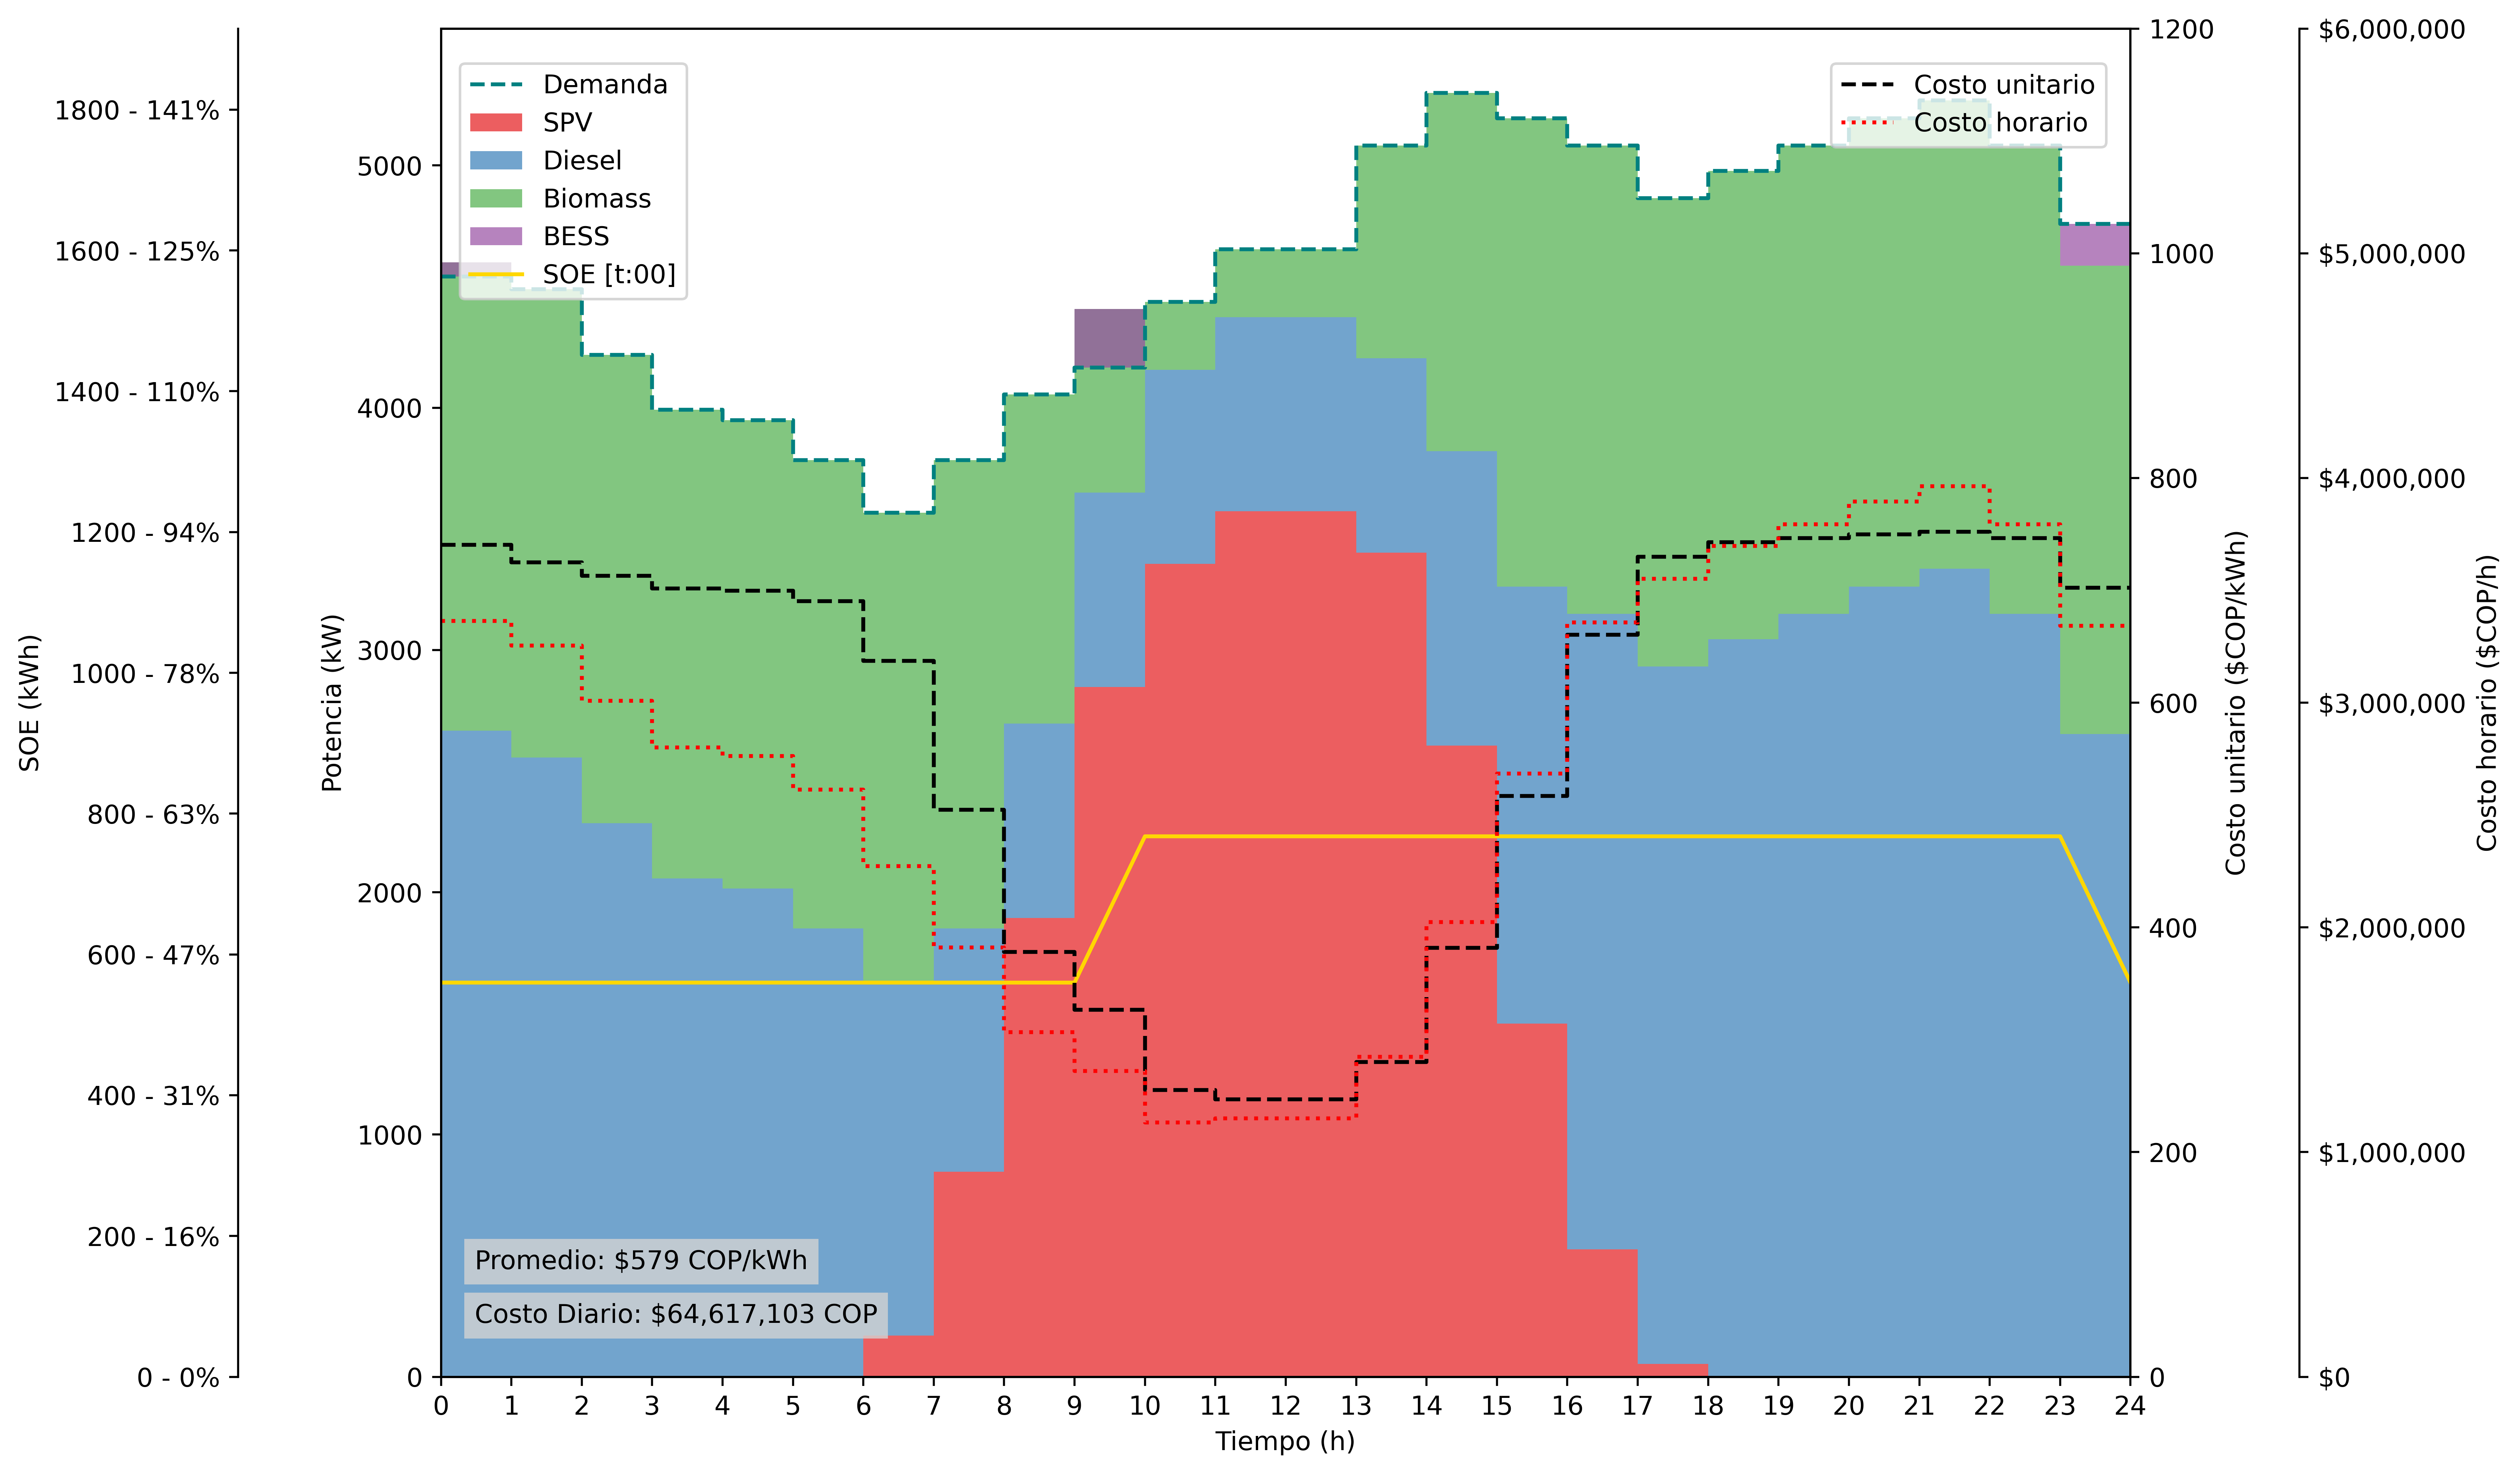

Nominal case day test:


c:\Users\seleg\OneDrive - Universidad Nacional de Colombia\GRAD\RESEARCH\Code\DROW_MMG\probEDNR.py:931: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(SOE_tick_labels)


KeyboardInterrupt: 

In [3]:
## DET NOMINAL CASE
MG1_nom=edr.detEDnR(MG1,**initopts)
print("Nominal ED:")
Res1_nom,Jis=MG1_nom.solve(plot_ED=True,**resopts)

# Set last instace for Op Tests
MG1_nom.LastInstance=LastInstanceGen

# Generate day sample
TESTDAY_MG1=MG1_nom.generateDaySample()

# Test it once
print("Nominal case day test:")
MG1_nom.MGOperation(Res1_nom,TESTDAY_MG1,plot_op=True)

# Generate Test sample set
TESTSET_MG1=MG1_nom.generateSampleSet(Ntests)

# Test it N times
Joos,PrViol=MG1_nom.Joos(Res1_nom,TESTSET_MG1)
AvgRecCost=Joos-Jis
print(f"Costo Reconcil. Promedio: ${AvgRecCost:,.0f} COP")
print(f"Joos: ${Joos:,.0f} COP = Jis(ED+R): {Jis:,.0f} + AvgRecCost: {AvgRecCost:,.0f}")
print(f"PrViol: {edr.vectoprint(PrViol,perc=True)}")


## ED+R Determinístico Caso Escenario Promedio
- Prueba en un día
- Prueba en $N$ días

[probEDNR.py:450 - __init__()] Instance set for non-transactive EDnR


Set parameter Username
Set parameter LicenseID to value 2708525


[probEDNR.py:477 - CreateModel()] Model "Jan09_111838" created
[probEDNR.py:458 - __init__()] No training sample provided for Model. Update using updateTrainSampleSet(trainSampleSet) if needed.
[probEDNR.py:1088 - heuristic_reserve()] Total Rsrv: +1.75MW, -1.59MW
[probEDNR.py:1089 - heuristic_reserve()] Freq Limits: -1.5Hz, 2Hz, 
[probEDNR.py:1090 - heuristic_reserve()] R_MG: 0.86Hz/MW, 7.571% puHz/puMW
[probEDNR.py:1121 - heuristic_reserve()] Equal droops r: 20.68% puHz/puMW
[probEDNR.py:1159 - heuristic_reserve()] Batt SOE bounds infeasible: 54.8% <= SOE <= 50.2%.
[probEDNR.py:1168 - heuristic_reserve()] Retrying with lower fpart_bess=32.0%
[probEDNR.py:1121 - heuristic_reserve()] Equal droops r: 18.25% puHz/puMW
[probEDNR.py:1190 - heuristic_reserve()] 43.86% <= SOE <= 60.13%
[probEDNR.py:1193 - heuristic_reserve()] For ['SPV', 'Diesel', 'Biomass', 'BESS']
[probEDNR.py:1194 - heuristic_reserve()] fpart: [0.0%, 50.5%, 17.5%, 32.0%]
[probEDNR.py:1195 - heuristic_reserve()] R: [100000.

Deterministic Avg ED:


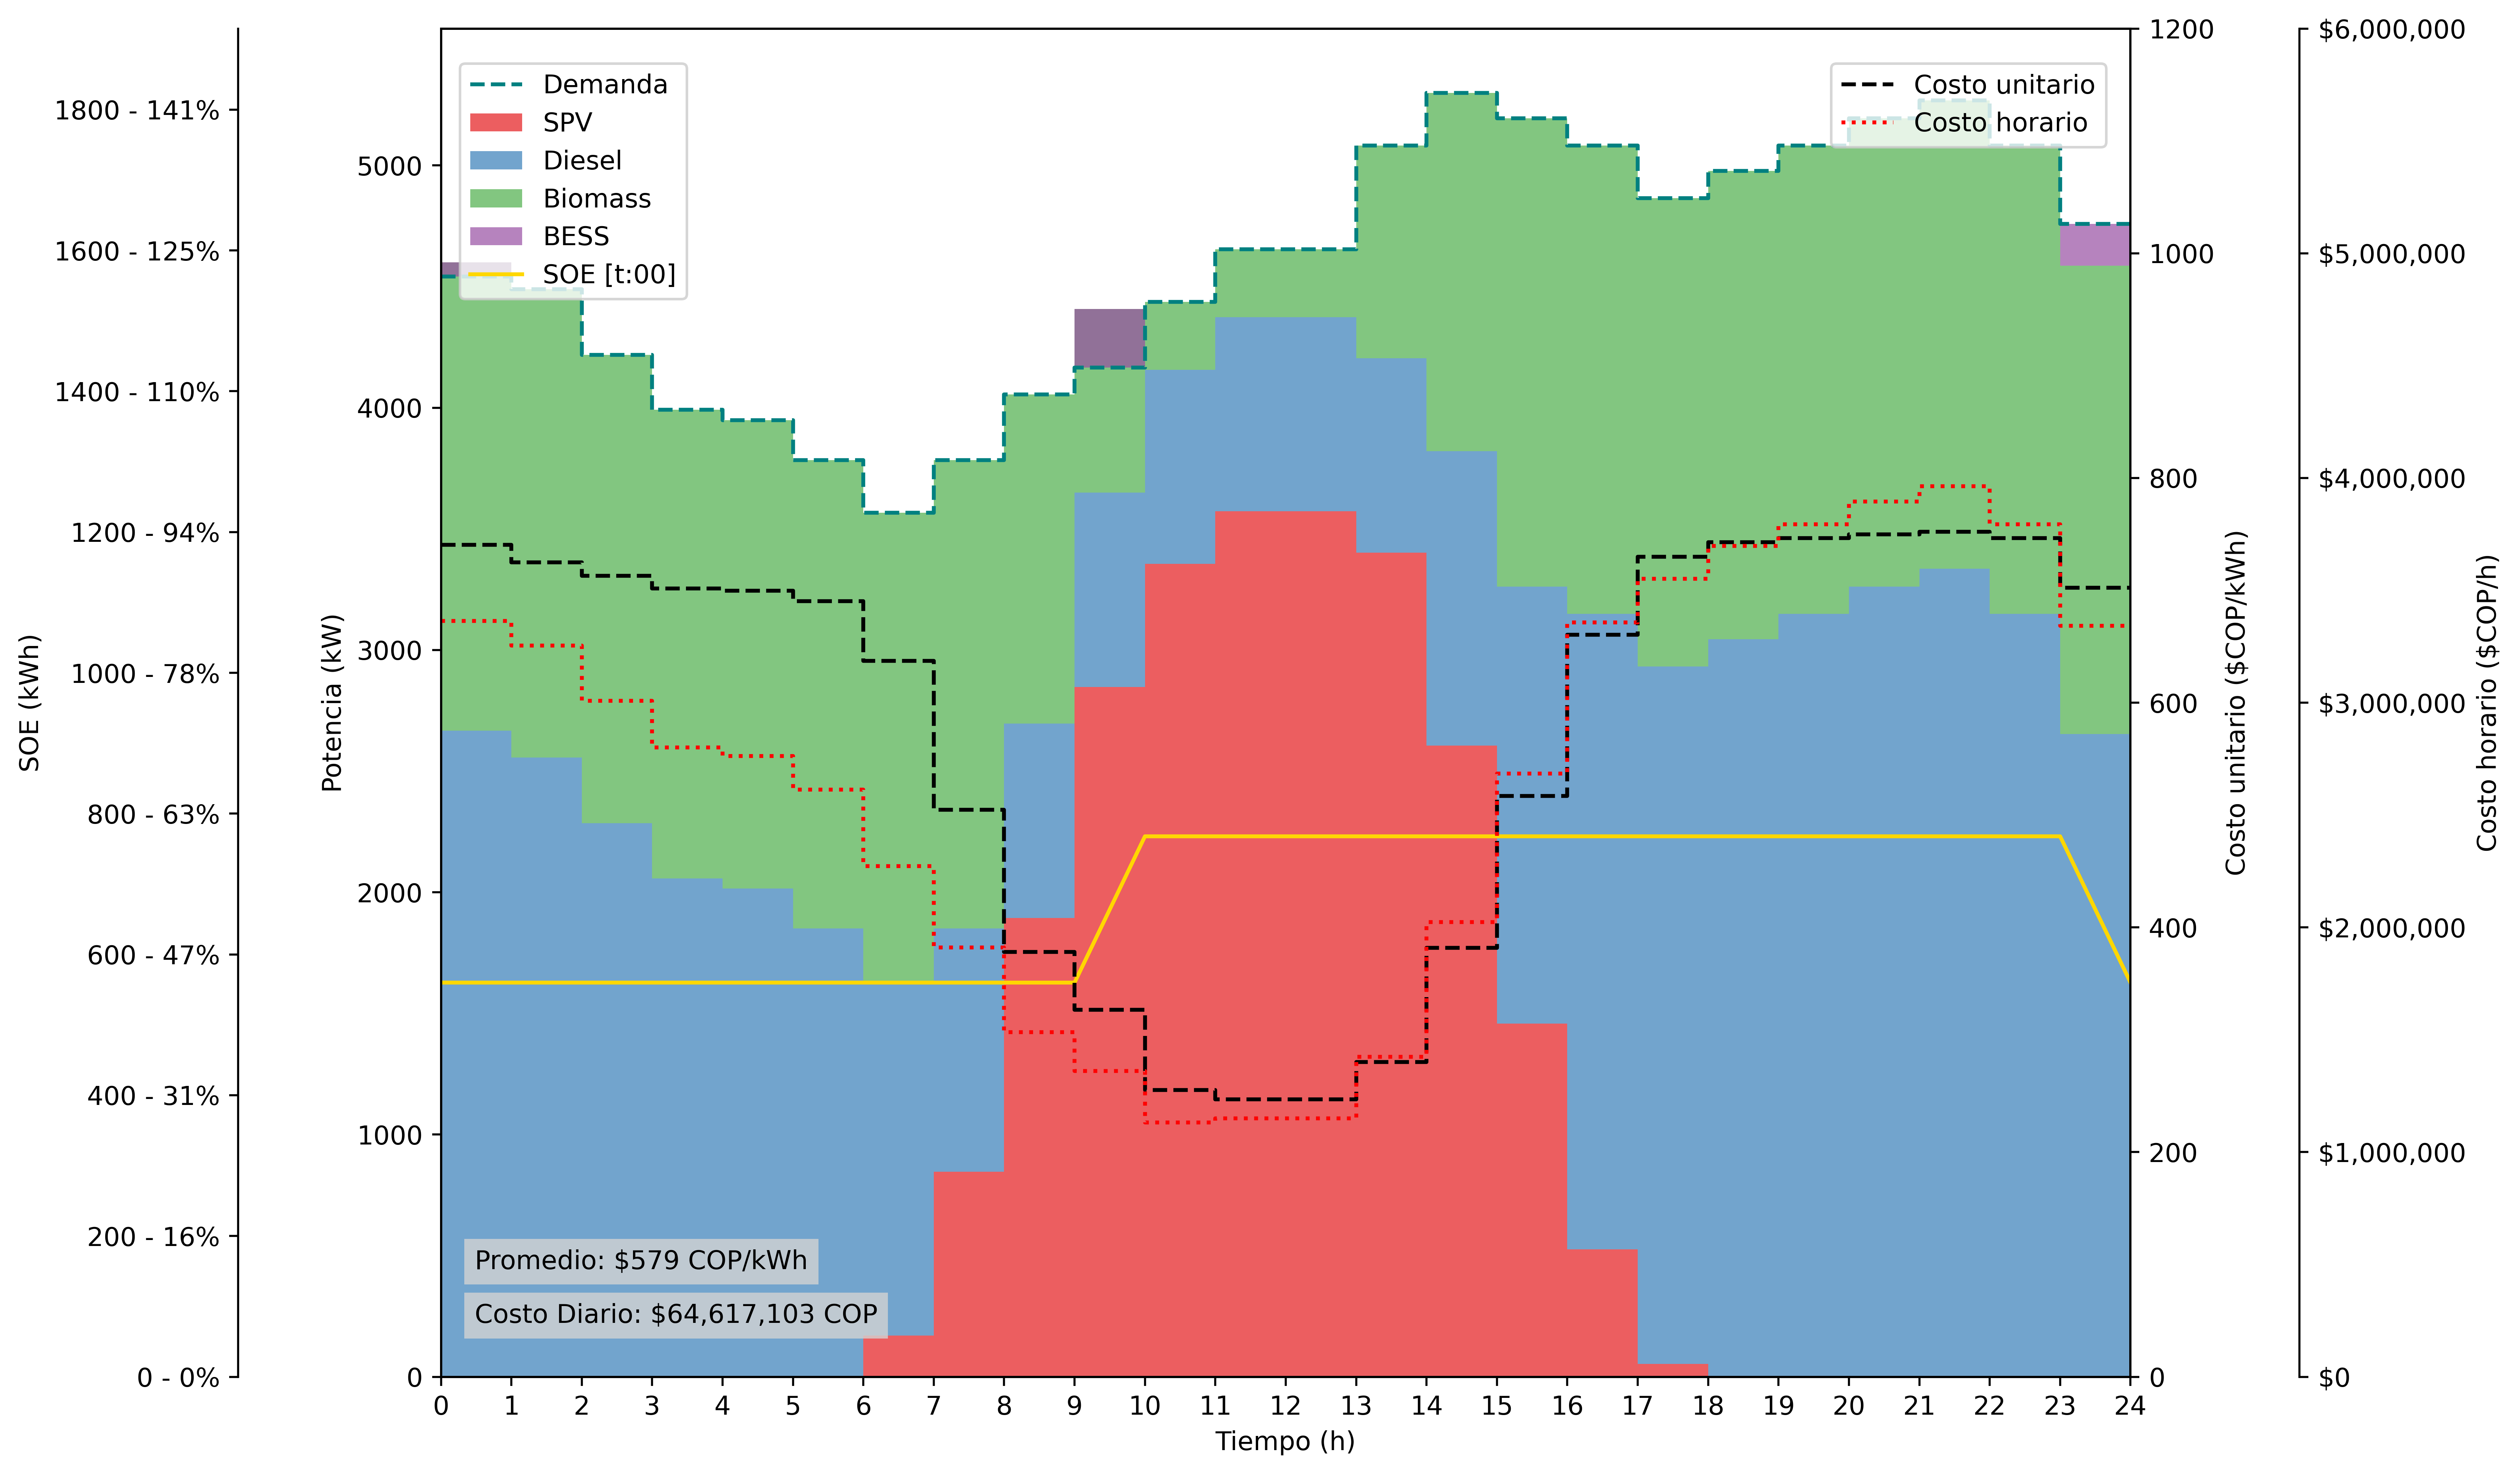

Deterministic Avg case day test:


c:\Users\seleg\OneDrive - Universidad Nacional de Colombia\GRAD\RESEARCH\Code\DROW_MMG\probEDNR.py:931: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(SOE_tick_labels)


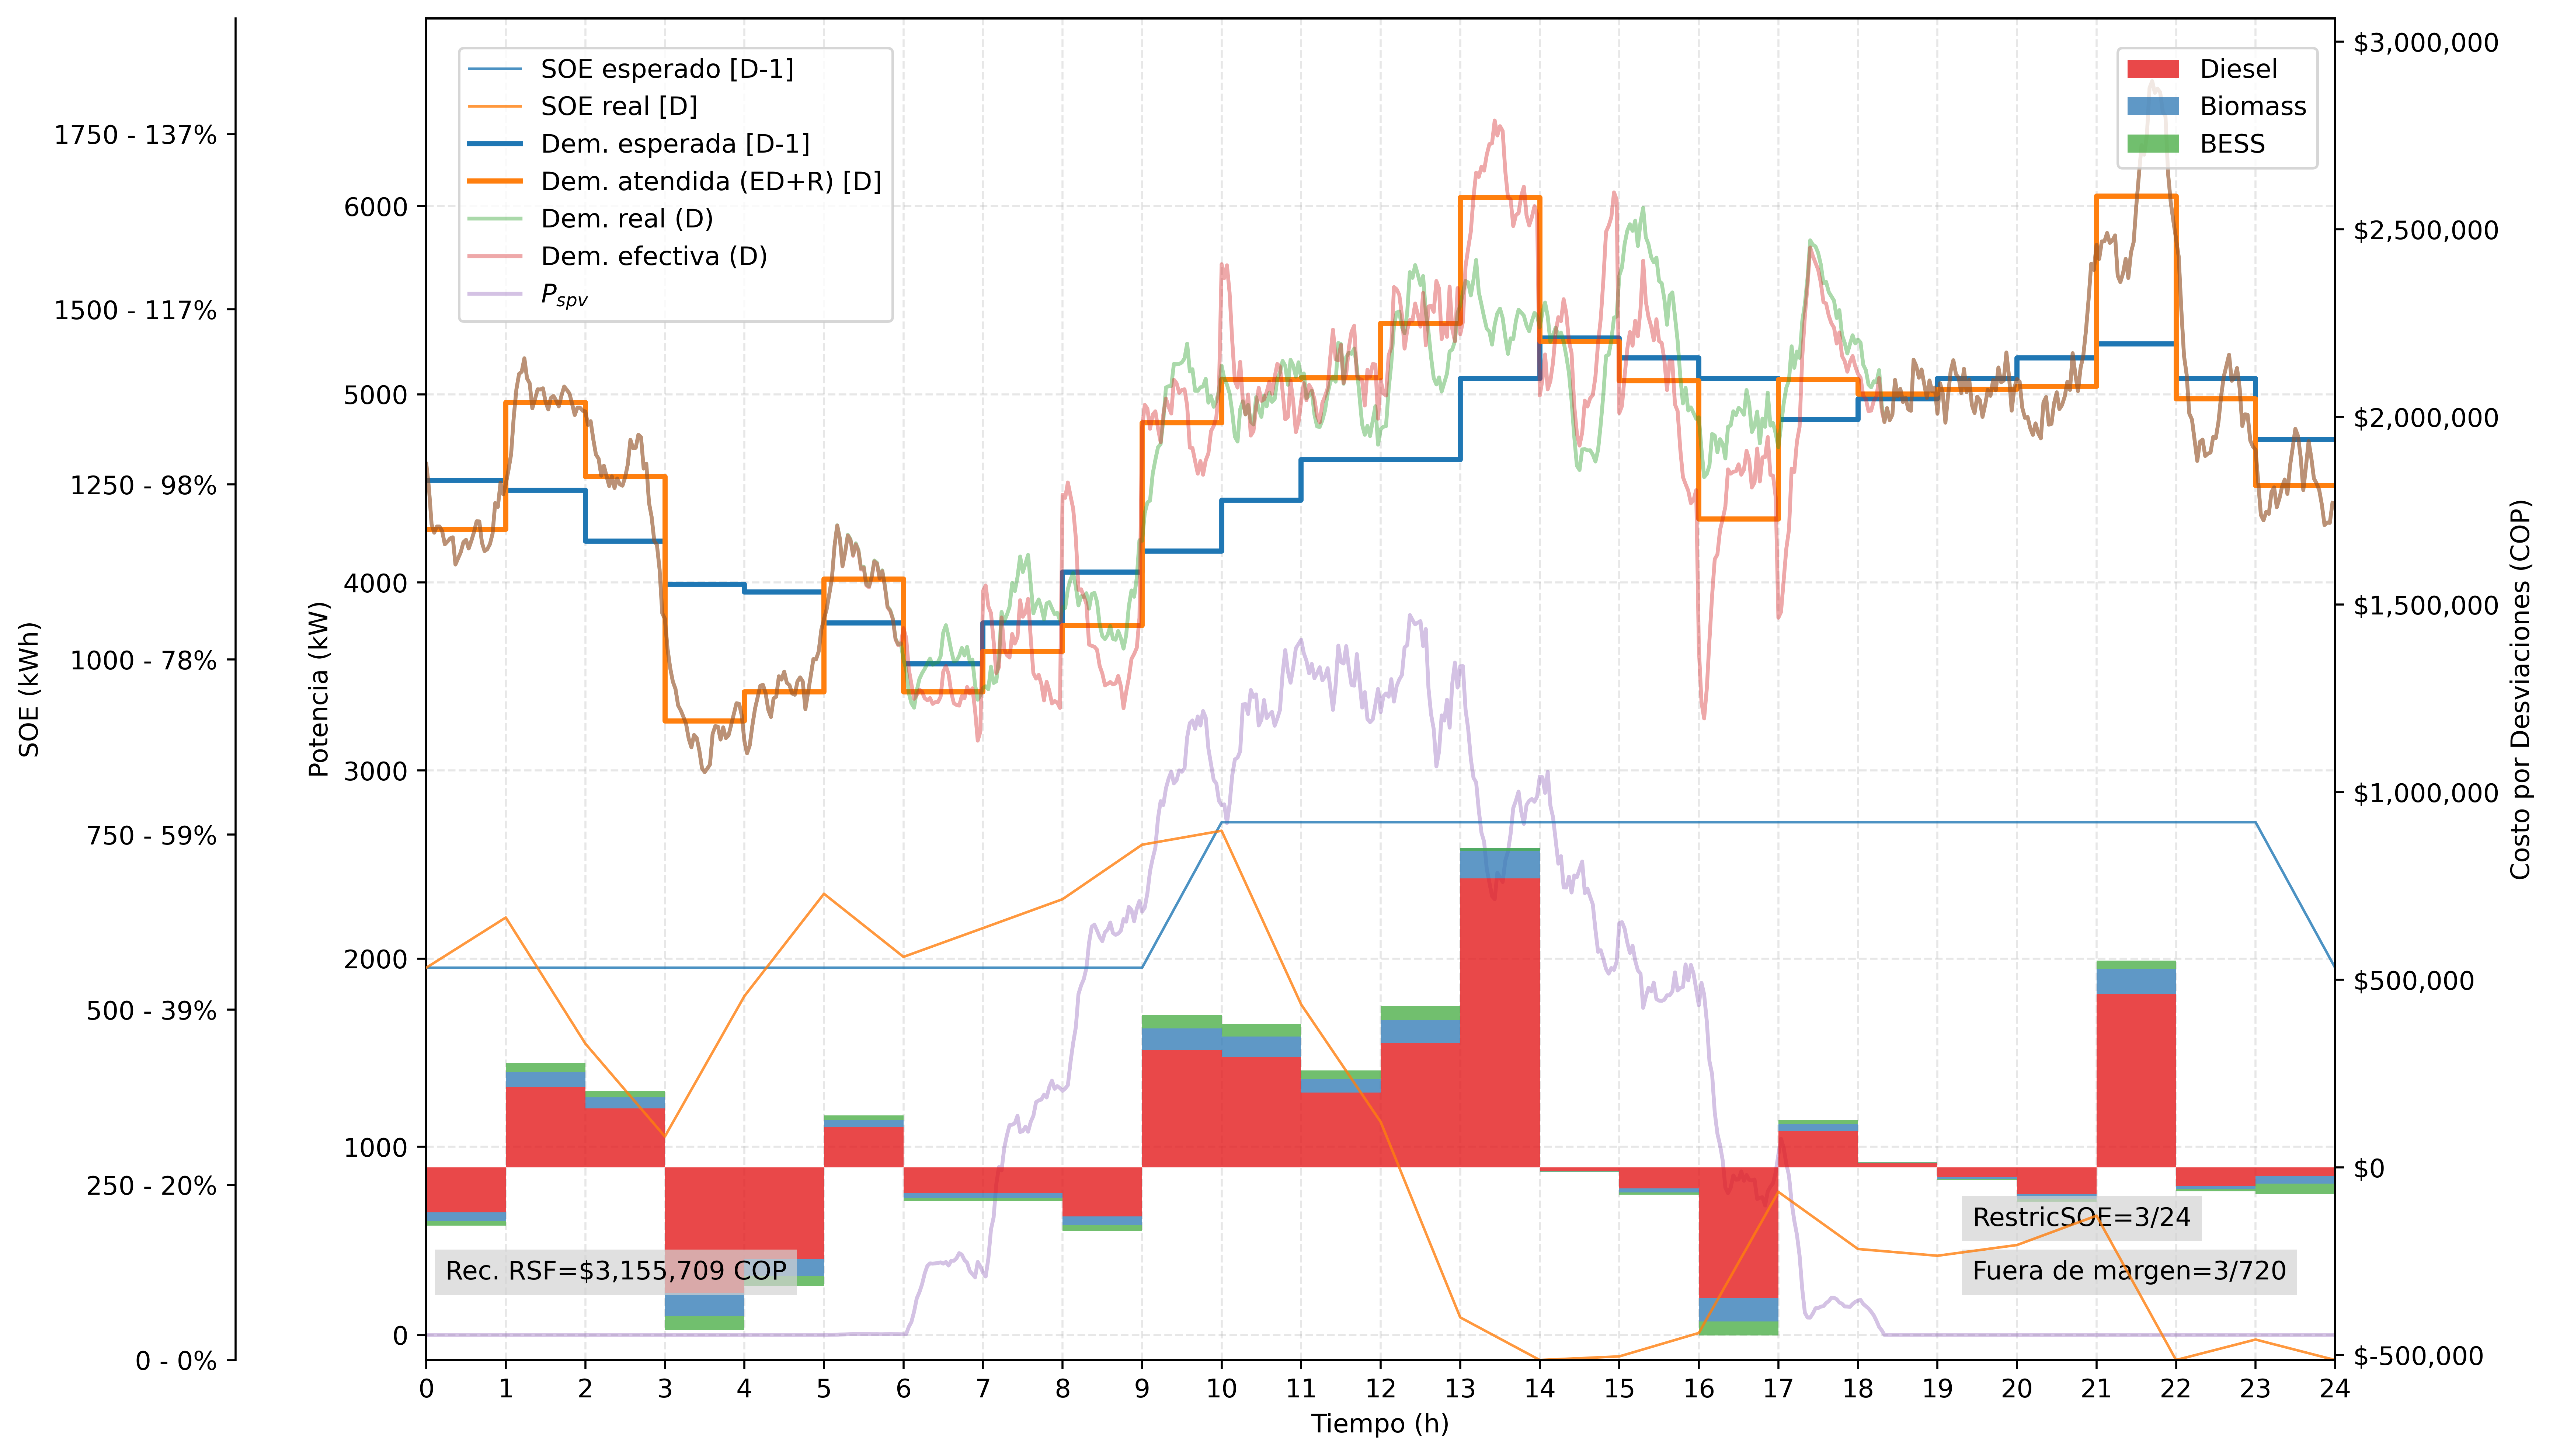

[probEDNR.py:178 - Joos()] Joos_: (66368184.732871376, 67597333.67454956, 60002402.00481798, 75567541.11650583, 85638939.71716471, 67878263.39409263, 70533604.44061382, 53657431.01257603, 49133856.169012845, 59779776.72265251)
[probEDNR.py:179 - Joos()] PrViol_: [(0.011111111111111112, 0.034722222222222224, 0.020833333333333332, 0.02361111111111111, 0.09583333333333334, 0.018055555555555554, 0.001388888888888889, 0.06388888888888888, 0.07916666666666666, 0.0), (0.041666666666666664, 0.20833333333333334, 0.4166666666666667, 0.625, 0.8333333333333334, 0.3333333333333333, 0.4583333333333333, 0.625, 0.875, 0.625)]
[probEDNR.py:181 - Joos()] Joos,PrViol: (65615733.29848572, array([0.03486111, 0.50416667]))


Costo Reconcil. Promedio: $998,631 COP
Joos: $65,615,733 COP = Jis(ED+R): 64,617,103 + AvgRecCost: 998,631
PrViol: ['[0]3.5%', '[1]50.4%']


In [ ]:
## DET AVG CASE
MG1_det=edr.detEDnR(MG1,**initopts)
print("Deterministic Avg ED:")
Res1_det,Jis=MG1_det.solve(plot_ED=True,**resopts)


# Set last instace for Op Tests
MG1_det.LastInstance=LastInstanceGen

# Test it once
print("Deterministic Avg case day test:")
MG1_det.MGOperation(Res1_det,TESTDAY_MG1,plot_op=True)


# Test it N times
Joos,PrViol=MG1_det.Joos(Res1_det,TESTSET_MG1)
AvgRecCost=Joos-Jis
print(f"Costo Reconcil. Promedio: ${AvgRecCost:,.0f} COP")
print(f"Joos: ${Joos:,.0f} COP = Jis(ED+R): {Jis:,.0f} + AvgRecCost: {AvgRecCost:,.0f}")
print(f"PrViol: {edr.vectoprint(PrViol,perc=True)}")
